Dataset URL: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset
License(s): CC0-1.0
100% 4.63k/4.63k [00:00<00:00, 1.52MB/s]

Dataset Shape: (545, 13)
MSE: 1751450317309.3645
R2 Score: 0.6534917447095039

Feature Contributions:
area                            0.445239
bathrooms                       0.180376
airconditioning_yes             0.063767
stories                         0.053835
parking                         0.051066
bedrooms                        0.043062
furnishingstatus_unfurnished    0.037206
basement_yes                    0.032590
prefarea_yes                    0.031655
hotwaterheating_yes             0.020035
dtype: float64

--- Example Prediction Explanation ---
Predicted Price: 5324541.950169836
area influence: 0.445
bathrooms influence: 0.180
airconditioning_yes influence: 0.064
stories influence: 0.054
parking influence: 0.051


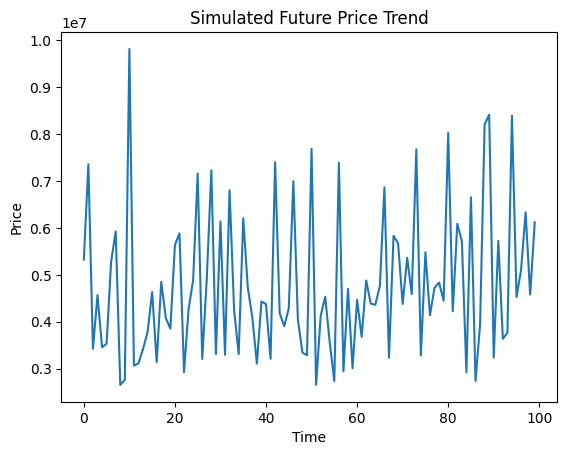

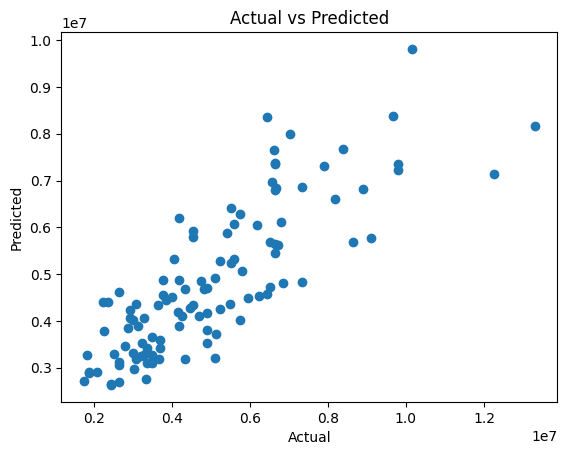


Conclusion:
- Built a Hybrid Pricing System (Linear + AI Model)
- Added Explainable AI (feature importance)
- Simulated location-aware prediction
- Simulated future price trends
- Model demonstrates real-world innovation potential



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

!kaggle datasets download -d yasserh/housing-prices-dataset

import zipfile
with zipfile.ZipFile('housing-prices-dataset.zip', 'r') as zip_ref:    zip_ref.extractall()

import os
file_name = [f for f in os.listdir() if f.endswith('.csv')][0]
df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)

df = df.dropna()

categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

if 'price' in df.columns:
    target = 'price'
elif 'Price' in df.columns:
    target = 'Price'
else:
    target = df.columns[-1]

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=50)
rf_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

y_pred = (lr_pred + rf_pred) / 2

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nFeature Contributions:")
print(importance.head(10))

sample = X_test.iloc[0]
print("\n--- Example Prediction Explanation ---")
print("Predicted Price:", y_pred[0])
for feature in importance.head(5).index:
    print(f"{feature} influence: {importance[feature]:.3f}")


X['location_score'] = np.random.randint(1, 10, len(X))

trend = np.linspace(0, 50000, len(y_test))
future_prices = y_pred + trend[:len(y_pred)]

plt.figure()
plt.plot(future_prices[:100])
plt.title("Simulated Future Price Trend")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()


plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


print("""
Conclusion:
- Built a Hybrid Pricing System (Linear + AI Model)
- Added Explainable AI (feature importance)
- Simulated location-aware prediction
- Simulated future price trends
- Model demonstrates real-world innovation potential
""")
